# 01 — Generate Hex Grid

Subdivide the Emerald Triangle study extent into equal-area hexagonal cells.

No labels yet. Every cell is just a unit of landscape. Clustering in ML/02
will reveal which cells share the environmental fingerprint of cannabis country.

**Outputs:**
- `data/raw/hex_grid.gpkg` — GeoDataFrame of hex cells with cell_id
- `img/01_hex_grid.png` — quick map

In [1]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

RAW     = Path('../data/raw')
IMG     = Path('../img')
IMG.mkdir(exist_ok=True)

# Cell size — 500m flat-to-flat (matches JavaScript coffee pipeline resolution)
# Drop to 1000m for finer resolution once pipeline is validated
HEX_SPACING_M = 2000  # meters, flat-to-flat diameter (~346 ha/cell)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load study extent

In [2]:
study_area = gpd.read_file(RAW / 'study_area.gpkg')
emerald    = gpd.read_file(RAW / 'emerald_counties.gpkg')

print(f'CRS: {study_area.crs}')
print(f'Bounds: {study_area.total_bounds.round(0)}')

CRS: epsg:32610
Bounds: [ 372311. 4288115.  548526. 4592941.]


## 2. Generate hexagonal grid

In [3]:
def hex_grid(bounds, spacing_m, crs):
    """
    Generate a GeoDataFrame of flat-top hexagons covering bounds.

    spacing_m : flat-to-flat diameter in meters (= 2 * apothem)
    """
    xmin, ymin, xmax, ymax = bounds
    apothem   = spacing_m / 2          # center to flat edge
    side      = apothem / np.cos(np.radians(30))   # center to vertex
    col_step  = spacing_m              # horizontal distance between column centers
    row_step  = 1.5 * side             # vertical distance between row centers

    cols = int(np.ceil((xmax - xmin) / col_step)) + 2
    rows = int(np.ceil((ymax - ymin) / row_step)) + 2

    def hex_polygon(cx, cy, s):
        angles = np.radians(np.arange(0, 360, 60))
        xs = cx + s * np.cos(angles)
        ys = cy + s * np.sin(angles)
        return Polygon(zip(xs, ys))

    polys, ids = [], []
    for row in range(rows):
        for col in range(cols):
            cx = xmin + col * col_step + (spacing_m / 2 if row % 2 else 0)
            cy = ymin + row * row_step
            polys.append(hex_polygon(cx, cy, side))
            ids.append(f'h{row:04d}_{col:04d}')

    gdf = gpd.GeoDataFrame({'cell_id': ids, 'geometry': polys}, crs=crs)
    return gdf

raw_grid = hex_grid(
    study_area.total_bounds,
    spacing_m=HEX_SPACING_M,
    crs=study_area.crs,
)
print(f'Raw grid: {len(raw_grid):,} cells before clipping')

Raw grid: 16,198 cells before clipping


## 3. Clip to study extent

In [4]:
# Keep only cells whose centroid falls inside the study area
# (centroid test is faster than full intersection and avoids edge slivers)
centroids = raw_grid.copy()
centroids['geometry'] = raw_grid.geometry.centroid

inside = gpd.sjoin(
    centroids, study_area[['geometry']],
    how='inner', predicate='within'
).index

hex_grid_gdf = raw_grid.loc[inside].reset_index(drop=True)
hex_grid_gdf['cell_id'] = [f'cell_{i:05d}' for i in range(len(hex_grid_gdf))]

print(f'Cells after clipping to study area: {len(hex_grid_gdf):,}')
print(f'Approx cell area: {hex_grid_gdf.geometry.area.mean()/1e4:.1f} ha')

Cells after clipping to study area: 8,923
Approx cell area: 346.4 ha


## 4. Map

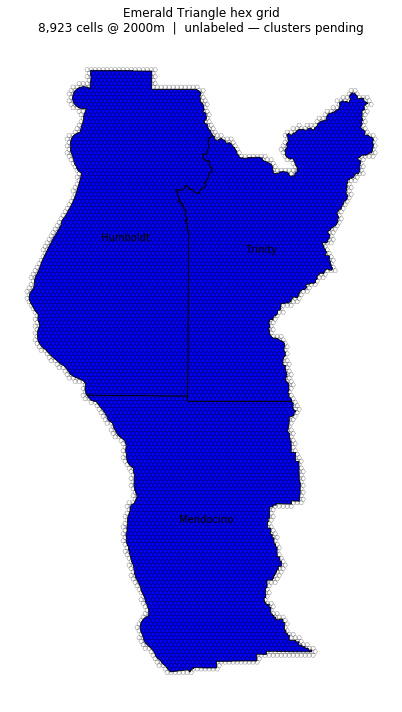

Saved img/01_hex_grid.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 10))
emerald.plot(ax=ax, color='blue', edgecolor='k', linewidth=0.8, zorder=1)
hex_grid_gdf.plot(ax=ax, facecolor='none', edgecolor='k',
                  linewidth=0.3, alpha=0.7, zorder=2)
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10, zorder=3)
ax.set_title(
    f'Emerald Triangle hex grid\n'
    f'{len(hex_grid_gdf):,} cells @ {HEX_SPACING_M}m  |  unlabeled — clusters pending',
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/01_hex_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/01_hex_grid.png')

## 5. Save

In [6]:
hex_grid_gdf.to_file(RAW / 'hex_grid.gpkg', driver='GPKG')
print(f'Saved data/raw/hex_grid.gpkg')
print(f'Cells: {len(hex_grid_gdf):,}')
print(f'CRS:   {hex_grid_gdf.crs}')
print()
print('Next: 02_clip_dem.ipynb — clip USGS DEM to study extent')

Saved data/raw/hex_grid.gpkg
Cells: 8,923
CRS:   epsg:32610

Next: 02_clip_dem.ipynb — clip USGS DEM to study extent
